In [8]:
"""
1D implementation of 
∂t phi_a= ∂x [D ∂x phi_a + phi_a(1-phi_a-phi_b)∂x pi_a +  sqrt(2D phi_a(1-phi_a-phi_b)) Z]
∂t phi_b= ∂x [D ∂x phi_b + phi_b(1-phi_a-phi_b)∂x pi_b +  sqrt(2D phi_b(1-phi_a-phi_b)) Z]
using a conservative finite-volume discretization and a stochastic (predictor-corrector) time integrator.

Features:
- Positivity floor for density
- multiplicative conservative noise (phi_a(1-phi_a-phi_b))
- Can be extended to the case with convolutional interaction potential using FFT (periodic)

Author: Tuan Pham and Wout Merbis
"""
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, irfft
from matplotlib.animation import FuncAnimation, PillowWriter
import fhd
import importlib
import time

importlib.reload(fhd)

<module 'fhd' from '/home/wmrs@cbsp.nl/codebase/fluctuating_hydro/fhd/__init__.py'>

In [9]:
N = 2**7
L = 50
simulator = fhd.fhd(L, N, bc= 'Neumann', fft=False)

In [21]:
T = 2/5
kappa_aa = kappa_bb = 1 - T
kappa_ab = - T 
kappa_ba = - T
# coupling matrix kappa  for pi^{(a)} = sum_b kappa_ab * (V * phi_b)
kappa = np.array([[kappa_aa, kappa_ab],
                  [kappa_ba, kappa_bb]])
D = 0.1*np.ones(2) # diffusion coefficient
Gamma = 1*np.eye(2) # Utility nabla^3 term coefficient
D_v = 0.001
noise_v = 1
beta = 1/D[0]

param = {'D': D, 'kappa': kappa, 'Gamma': Gamma, 'D_v' : D_v, 'beta': beta, 'noise_v': noise_v}

x = simulator.x
nspecies = simulator.nspecies
N = simulator.N
L = simulator.L

phi = np.zeros((nspecies, N))
phi0 = 0.4
pert_amp = 0.0
phi[0,:] =phi0 + pert_amp * np.cos(2*np.pi*x / L * 2) + 0.05 * np.random.normal(size=N) 
#phi0 + pert_amp * np.cos(2*np.pi*x / L * 6) + 0.005 * np.random.normal(size=N) 
# np.exp(-(x+L//8)**2/(2*(L//12)**2)) 
#  0.5*(np.tanh(-x)+1)/2
phi[1,:] = phi0 + pert_amp * np.sin(2*np.pi*x / L * 2) + 0.05 * np.random.normal(size=N) 
#phi0 + pert_amp * np.sin(2*np.pi*x / L * 6) + 0.005 * np.random.normal(size=N) 
# np.exp(-(x-L//8)**2/(2*(L//12)**2)) 
# 0.5*(np.tanh(x)+1)/2


Step 5000/500000: mean rho = 0.404230, min = 3.522986e-01, D_index = 0.061716
Step 10000/500000: mean rho = 0.404214, min = 3.528656e-01, D_index = 0.056354
Step 15000/500000: mean rho = 0.404200, min = 3.525270e-01, D_index = 0.054149
Step 20000/500000: mean rho = 0.404188, min = 3.518019e-01, D_index = 0.053540
Step 25000/500000: mean rho = 0.404177, min = 3.508946e-01, D_index = 0.053811
Step 30000/500000: mean rho = 0.404166, min = 3.498778e-01, D_index = 0.054724
Step 35000/500000: mean rho = 0.404155, min = 3.487722e-01, D_index = 0.056025
Step 40000/500000: mean rho = 0.404143, min = 3.475791e-01, D_index = 0.057710
Step 45000/500000: mean rho = 0.404131, min = 3.462939e-01, D_index = 0.059765
Step 50000/500000: mean rho = 0.404118, min = 3.449108e-01, D_index = 0.062191
Step 55000/500000: mean rho = 0.404105, min = 3.434241e-01, D_index = 0.065003
Step 60000/500000: mean rho = 0.404090, min = 3.418285e-01, D_index = 0.068220
Step 65000/500000: mean rho = 0.404074, min = 3.40119

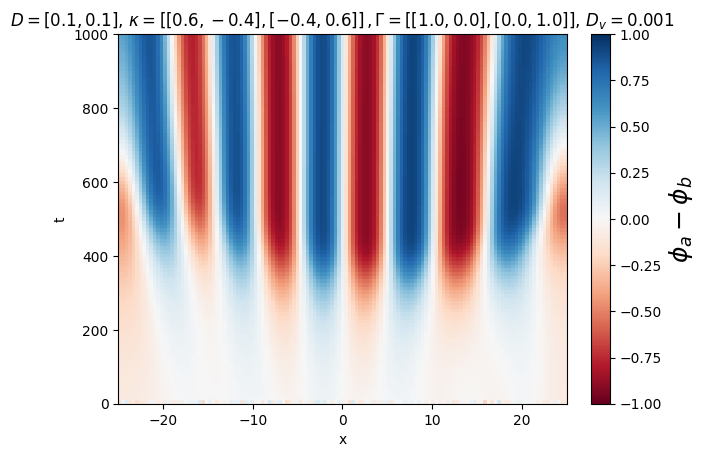

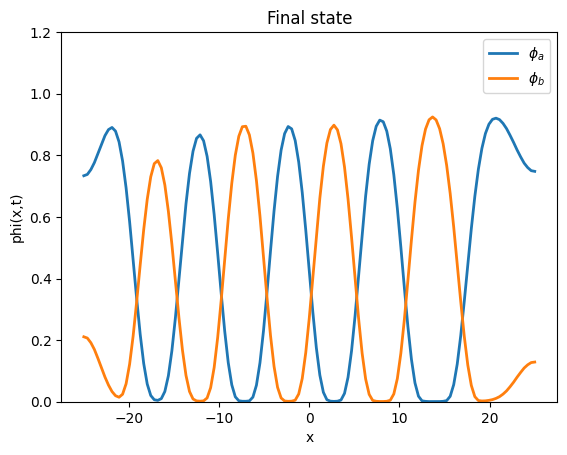

Simulation terminated in t = 89.955319s


In [22]:
dt = 0.002 
nsteps = 500000
noise = 0
frames = 100

st = time.time()
phi_run = simulator.run(phi, param, nsteps, dt, noise, frames, model = "Schelling+Voter")
et = time.time()
print(f"Simulation terminated in t = {et-st:.6f}s")

In [26]:
N = 2**7
L = 50
simulator = fhd.fhd(L, N, bc= 'Neumann', fft=False)

T = 2/5
kappa_aa = kappa_bb = 1 - T
kappa_ab = - T 
kappa_ba = - T
# coupling matrix kappa  for pi^{(a)} = sum_b kappa_ab * (V * phi_b)
kappa = np.array([[kappa_aa, kappa_ab],
                  [kappa_ba, kappa_bb]])
D = 0.1*np.ones(2) # diffusion coefficient
Gamma = 1*np.eye(2) # Utility nabla^3 term coefficient
D_v = 0.0
noise_v = 1
beta = 1/D[0]

param = {'D': D, 'kappa': kappa, 'Gamma': Gamma, 'D_v' : D_v, 'beta': beta, 'noise_v': noise_v}

x = simulator.x
nspecies = simulator.nspecies
N = simulator.N
L = simulator.L

Dv_space = np.linspace(0,0.16,17)
rho_space = np.linspace(0.1,0.9,9)

H_indices = np.zeros((len(Dv_space), len(rho_space)))
D_indices = np.zeros((len(Dv_space), len(rho_space)))

dt = 0.002 
nsteps = 500000
noise = 0
frames = 100

for i, D_v in enumerate(Dv_space):
    print(f"Starting D_v = {D_v}")
    param['D_v'] = D_v

    for j, rho_tot in enumerate(rho_space):
        phi = np.zeros((nspecies, N))
        phi0 = rho_tot/2
        pert_amp = 0.0
        phi[0,:] =phi0 + pert_amp * np.cos(2*np.pi*x / L * 2) + 0.05 * np.random.normal(size=N) 
        phi[1,:] = phi0 + pert_amp * np.sin(2*np.pi*x / L * 2) + 0.05 * np.random.normal(size=N) 
        phi[phi<0] = 1e-6

        st = time.time()
        phi_run = simulator.run(phi, param, nsteps, dt, noise, frames, model = "Schelling+Voter", verbatum=False)
        et = time.time()
        print(f"Simulation for rho = {rho_tot} terminated in t = {et-st:.6f}s")

        H_indices[i,j] = fhd.entropy_index(phi_run[:,-1])
        D_indices[i,j] = fhd.dissimilarity(phi_run[:,-1])
        np.save(f"data/sweep1/run_theta04_Dv_{D_v:.2f}_rho_{rho_tot:.2f}", phi_run)

Starting D_v = 0.0
Simulation for rho = 0.1 terminated in t = 83.722128s
Simulation for rho = 0.2 terminated in t = 84.058861s
Simulation for rho = 0.30000000000000004 terminated in t = 84.771524s
Simulation for rho = 0.4 terminated in t = 84.560091s
Simulation for rho = 0.5 terminated in t = 84.645657s
Simulation for rho = 0.6 terminated in t = 84.622411s
Simulation for rho = 0.7000000000000001 terminated in t = 85.023262s
Simulation for rho = 0.8 terminated in t = 84.026367s
Simulation for rho = 0.9 terminated in t = 84.375420s
Starting D_v = 0.01
Simulation for rho = 0.1 terminated in t = 84.581949s
Simulation for rho = 0.2 terminated in t = 84.294906s
Simulation for rho = 0.30000000000000004 terminated in t = 84.574646s
Simulation for rho = 0.4 terminated in t = 83.949509s
Simulation for rho = 0.5 terminated in t = 84.068441s
Simulation for rho = 0.6 terminated in t = 84.908201s
Simulation for rho = 0.7000000000000001 terminated in t = 85.346930s
Simulation for rho = 0.8 terminated

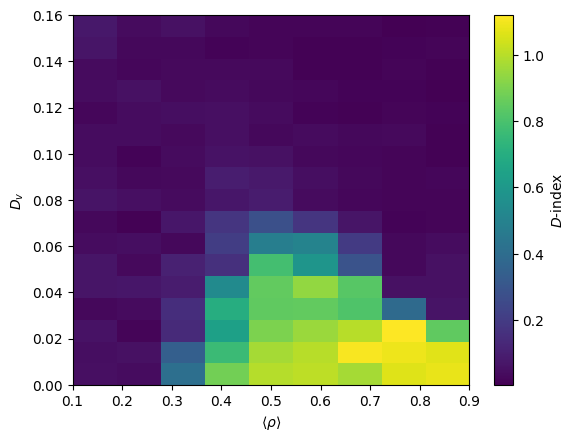

In [39]:
plt.imshow(D_indices, cmap='viridis', aspect = "auto", extent = (0.1,0.9,0.,0.16), origin='lower')
plt.colorbar(label=r"$D$-index")
plt.xlabel(r"$\langle \rho \rangle$")
plt.ylabel(r"$D_v$")
plt.show()

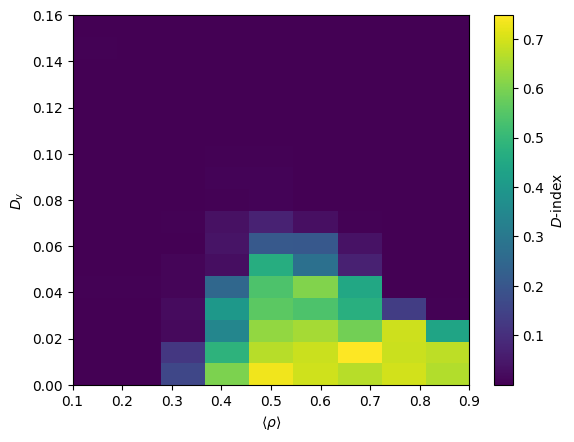

In [40]:
plt.imshow(H_indices, cmap='viridis', aspect = "auto", extent = (0.1,0.9,0.,0.16), origin='lower')
plt.colorbar(label=r"$D$-index")
plt.xlabel(r"$\langle \rho \rangle$")
plt.ylabel(r"$D_v$")
plt.show()

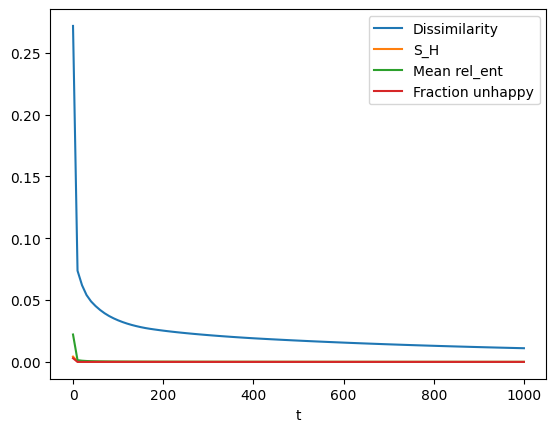

In [41]:
theta = 2/5

Rel_ent = np.array([fhd.mean_relative_entropy(phi_run[:,t]) for t in range(frames+1)])
Dis_idx = np.array([fhd.dissimilarity(phi_run[:,t]) for t in range(frames+1)])
Q_unhappy = np.array([fhd.fraction_unhappy(theta, phi_run[:,t]) for t in range(frames+1)])
S_H = np.array([fhd.entropy_index(phi_run[:,t]) for t in range(frames + 1)])

t = np.linspace(0, dt*nsteps, frames+1)
plt.plot(t,Dis_idx, label = "Dissimilarity")
plt.plot(t,S_H, label = "S_H")
plt.plot(t,Rel_ent,  label = "Mean rel_ent")
plt.plot(t,Q_unhappy, label = "Fraction unhappy")
plt.xlabel("t")
plt.legend()
plt.show()

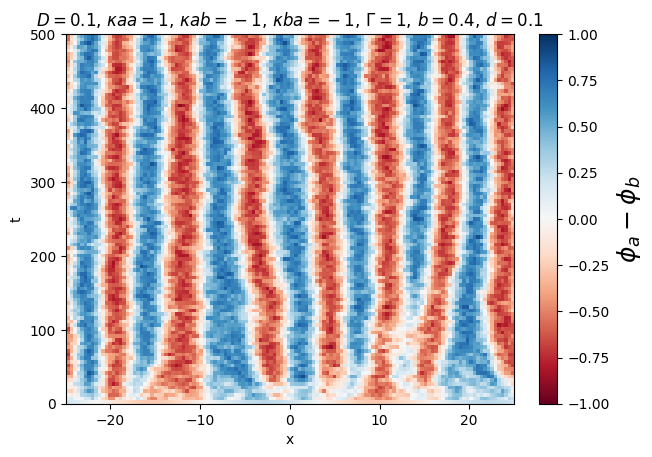

In [65]:
phi_diff = phi_run[0,:,:] - phi_run[1,:,:]
# t = np.linspace(0,dt*nsteps, plot_every+1)
im =plt.imshow(phi_diff, cmap = 'RdBu', aspect='auto', origin='lower', extent=[-L/2,L/2,0,dt*nsteps], vmin=-1, vmax=1)
plt.title(fr"$D = {D},\, \kappa aa = {kappa_aa},\, \kappa ab = {kappa_ab},\, \kappa ba = {kappa_ba},\, \Gamma = { Gamma}, \, b={b}, \, d={d} $")
plt.xlabel("x")
plt.ylabel("t")
cbar = plt.colorbar(im, fraction=0.046)
cbar.set_label(r"$\phi_a - \phi_b$",size=18)
# plt.savefig("fhd_plots/integrating_tanh_noisy_reactions.pdf")
plt.show()


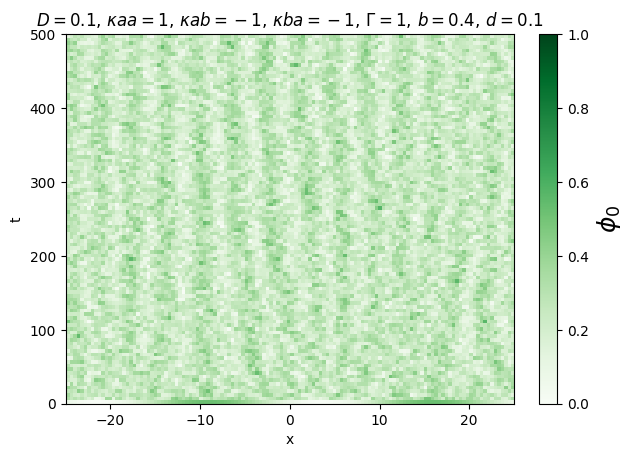

In [66]:
phi0 = 1 - phi_run[0,:,:] - phi_run[1,:,:]
# t = np.linspace(0,dt*nsteps, plot_every+1)
im =plt.imshow(phi0, cmap = 'Greens', aspect='auto', origin='lower', extent=[-L/2,L/2,0,dt*nsteps], vmin=0, vmax=1)
plt.title(fr"$D = {D},\, \kappa aa = {kappa_aa},\, \kappa ab = {kappa_ab},\, \kappa ba = {kappa_ba},\, \Gamma = { Gamma}, \, b={b}, \, d={d} $")
plt.xlabel("x")
plt.ylabel("t")
cbar = plt.colorbar(im, fraction=0.046)
cbar.set_label(r"$\phi_0$",size=18)
# plt.savefig("fhd_plots/phi0_integrated_tanh_with_noise.pdf")
plt.show()


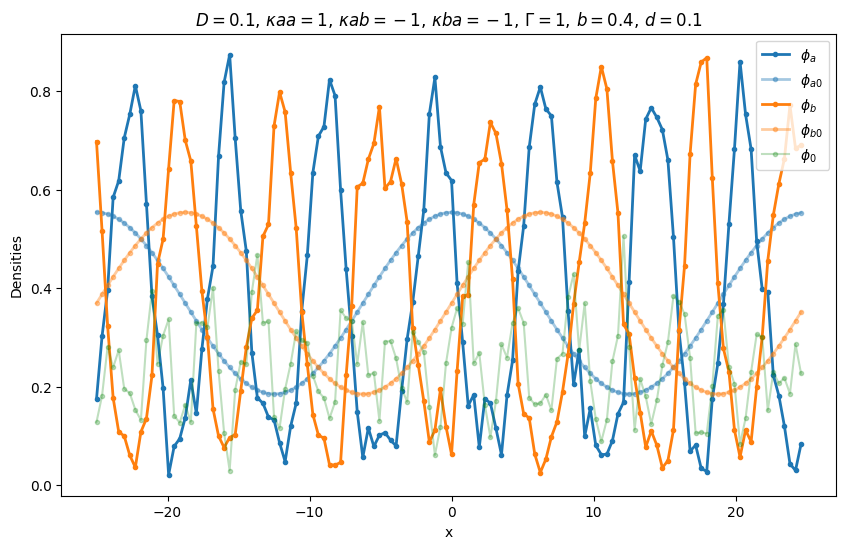

In [67]:
fig, ax = plt.subplots(figsize=(10,6))
ep = -1
line_phi = []
colors = ['C0', 'C1']
labels = [r'$\phi_a$', r'$\phi_b$']
labelnew = [r'$\phi_a$', r'$\phi_b$', r'$\phi_a + \phi_b$']
for a in range(nspecies):
    ln, = ax.plot(x, phi_run[a,ep], lw=2, color=colors[a], label=labels[a], marker = '.')
    ln, = ax.plot(x, phi_run[a,0], lw=2, color=colors[a], label=labels[a]+"${}_0$", marker = '.', alpha=0.4)
    line_phi.append(ln)
#line_phi.append(ax.plot(x, phi_tot, lw=2,c='k', label=labelnew[2]))
ax.plot(x, 1-phi_run[:,ep,:].sum(axis=0), color = 'g', label= r'$\phi_0$', marker = '.', alpha=0.25)
# ax.set_ylim(1e-8, 1.05)
ax.set_xlabel('x')
# ax.set_yscale('log')
plt.title(fr"$D = {D},\, \kappa aa = {kappa_aa},\, \kappa ab = {kappa_ab},\, \kappa ba = {kappa_ba},\, \Gamma = { Gamma}, \, b={b}, \, d={d} $")
ax.set_ylabel('Densities')
ax.legend()
plt.show()


In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML


t = phi_run.shape[1]  # Number of time steps


# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))
line_phi = []
colors = ['C0', 'C1', 'C2']
labels = [r'$\phi_a$', r'$\phi_b$', r'$\phi_0$']

# Initialize the plot lines
for a in range(2):
    ln, = ax.plot(x, phi_run[a,0], lw=2, color=colors[a], label=labels[a], marker='.')
    line_phi.append(ln)

phi0 =  1-phi_run[:,0].sum(axis=0)
ln, = ax.plot(x, phi0, lw =2, color = colors[2], label = labels[2], marker = '.')
line_phi.append(ln)

ax.set_ylim([0,1])
ax.set_xlabel('x')
ax.set_ylabel('Densities')
ax.legend(loc = "upper right")

# Title with parameters
title = fr"$D = {D},\, \kappa aa = {kappa_aa},\, \kappa ab = {kappa_ab},\, \kappa ba = {kappa_ba},\, \Gamma = {Gamma}, \, b={b}, \, d={d} $"
plt.title(title)

# Update function for animation
def update(frame):
    for a in range(2):
        line_phi[a].set_data(x, phi_run[a, frame])
    line_phi[2].set_data(x, 1- phi_run[:,frame].sum(axis=0))
    return line_phi

# Create animation
ani = animation.FuncAnimation(fig, update, frames=t, blit=True)

# Save animation as GIF
# ani.save('fhd_plots/migrating_long_run.gif', writer='pillow')
HTML(ani.to_jshtml())
